# 7 &middot; Time Integration: Forward Euler, Backward Euler, BDF2

To animate motion we march the equations of motion in time. The **integrator**
trades accuracy against stability and damping. We compare three on the *same*
cantilever beam:

| scheme | type | order | character |
|---|---|---|---|
| **Forward Euler** | explicit | 1 | cheap, but explodes unless dt is tiny |
| **Backward Euler** | implicit | 1 | rock-solid, but adds numerical damping |
| **BDF2** | implicit | 2 | second-order accurate, barely damps |

Each implicit step minimizes the potential plus an **inertia** term
\(\tfrac{c}{2h^2}\lVert x - \tilde x\rVert_M^2\) pulling \(x\) toward where
inertia says it should go (\(\tilde x\)). We write the three steppers explicitly
so the only thing that changes is \(\tilde x\) and \(c\).

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.solvers.NewtonSolver import NewtonSolver, NewtonSolverParams
import utils
os.makedirs("media", exist_ok=True)

## The beam and a readable potential

`pot_*` are the static potential (elastic + pinned left edge - gravity). Each
integrator adds its own inertia term on top.

In [2]:
X, T = utils.triangulated_grid(nx=14, ny=4, width=2.0, height=0.3)
n, dim = X.shape
J, vol = simkit.deformation_jacobian(X, T), simkit.volume(X, T)
M_n = simkit.massmatrix(X, T, rho=1.0)
M   = sp.sparse.kron(M_n, sp.sparse.eye(dim)).tocsc()
M_lumped = np.asarray(M.sum(1)).flatten()                 # for explicit Forward Euler
f_g = simkit.gravity_force(X, T, a=-9.8, rho=1.0).reshape(-1, 1)
mu, lam = simkit.ympr_to_lame(500.0, 0.4)
mu  = np.full((len(T), 1), mu)
lam = np.full((len(T), 1), lam)
pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, 1e7)

def pot_energy(x):
    xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
    E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, J, mu, lam, vol)
    E_pin     = 0.5 * (xc.T @ (Q_pin @ xc))[0, 0] + (b_pin.T @ xc)[0, 0]
    E_gravity = -(f_g.T @ xc)[0, 0]
    E_total   = E_elastic + E_pin + E_gravity
    return E_total
def pot_gradient(x):
    xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
    g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, J, mu, lam, vol)
    g_pin     = Q_pin @ xc + b_pin
    g_gravity = -f_g
    g_total   = g_elastic + g_pin + g_gravity
    return g_total
def pot_hessian(x):
    xn = x.reshape(-1, dim)
    H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, J, mu, lam, vol, psd=True)
    H_pin     = Q_pin
    H_total   = H_elastic + H_pin
    return H_total

def newton(energy, gradient, hessian, x0, iters=30):
    return NewtonSolver(energy, gradient, hessian,
                        NewtonSolverParams(max_iter=iters, do_line_search=True)
                        ).solve(x0.reshape(-1, 1)).reshape(n, dim)

## The three steppers

Each takes the current state and returns the next. The implicit ones (BE, BDF2)
minimize `pot + inertia` &mdash; and differ *only* in the inertia target
\(\tilde x\) and the constant \(c\), so we factor that shared minimize into
`implicit_step`. Forward Euler is a plain explicit update. We carry an explicit
velocity `V` so BDF2 is genuinely second order.

In [3]:
def implicit_step(U, x_tilde, c, h):
    """Minimize  pot(x) + inertia(x),  inertia = c/(2 h^2) ||x - x_tilde||^2_M."""
    def energy(x):
        xc = x.reshape(-1, 1)
        E_pot     = pot_energy(x)
        E_inertia = 0.5 * c * ((xc - x_tilde).T @ (M @ (xc - x_tilde)))[0, 0] / h**2
        E_total   = E_pot + E_inertia
        return E_total
    def gradient(x):
        xc = x.reshape(-1, 1)
        g_pot     = pot_gradient(x)
        g_inertia = c * (M @ (xc - x_tilde)) / h**2
        g_total   = g_pot + g_inertia
        return g_total
    def hessian(x):
        H_pot     = pot_hessian(x)
        H_inertia = c * M / h**2
        H_total   = H_pot + H_inertia
        return H_total
    return newton(energy, gradient, hessian, U)

def fe_step(U, V, h):
    """Forward (explicit) Euler:  a = M^-1 (-grad pot);  x += h v;  v += h a."""
    a = (-pot_gradient(U).flatten() / M_lumped).reshape(n, dim)
    U_next = U + h * V
    V_next = V + h * a
    U_next[pin_idx] = X[pin_idx]; V_next[pin_idx] = 0.0      # hard-clamp the pins
    return U_next, V_next

def be_step(U, V, h):
    """Backward Euler:  inertia target x_tilde = U + h V,  c = 1."""
    x_tilde = (U + h * V).reshape(-1, 1)
    U_next  = implicit_step(U, x_tilde, 1.0, h)
    V_next  = (U_next - U) / h
    return U_next, V_next

def bdf2_step(U, V, U_prev, V_prev, h):
    """BDF2:  x_tilde = 4/3 U - 1/3 U_prev + 8h/9 V - 2h/9 V_prev,  c = 9/4."""
    x_tilde = ((4/3) * U - (1/3) * U_prev + (8*h/9) * V - (2*h/9) * V_prev).reshape(-1, 1)
    U_next  = implicit_step(U, x_tilde, 9.0/4.0, h)
    V_next  = (3 * U_next - 4 * U + U_prev) / (2 * h)
    return U_next, V_next

## Drivers that snapshot at fixed times

So we can compare runs with very different timesteps on the same time axis.

In [4]:
def simulate_fe(h, T_total, n_frames=60):
    sample = np.linspace(0, T_total, n_frames)
    U, V, t, si, frames = X.copy(), np.zeros_like(X), 0.0, 0, [X.copy()]
    while si < n_frames - 1:
        U, V = fe_step(U, V, h); t += h
        if not np.isfinite(U).all() or np.abs(U).max() > 1e3:        # exploded
            frames += [U.copy()] * (n_frames - len(frames)); break
        while si < n_frames - 1 and t >= sample[si + 1]:
            si += 1; frames.append(U.copy())
    return frames

def simulate_be(h, T_total, n_frames=60):
    sample = np.linspace(0, T_total, n_frames)
    U, V, t, si, frames = X.copy(), np.zeros_like(X), 0.0, 0, [X.copy()]
    while si < n_frames - 1:
        U, V = be_step(U, V, h); t += h
        while si < n_frames - 1 and t >= sample[si + 1]:
            si += 1; frames.append(U.copy())
    return frames

def simulate_bdf2(h, T_total, n_frames=60):
    sample = np.linspace(0, T_total, n_frames)
    U, V = X.copy(), np.zeros_like(X)
    U_next, V_next = be_step(U, V, h)                  # bootstrap one BE step
    U_prev, V_prev, U, V = U, V, U_next, V_next
    t, si, frames = h, 0, [X.copy()]
    while si < n_frames - 1:
        U_next, V_next = bdf2_step(U, V, U_prev, V_prev, h)
        U_prev, V_prev, U, V = U, V, U_next, V_next; t += h
        while si < n_frames - 1 and t >= sample[si + 1]:
            si += 1; frames.append(U.copy())
    return frames

## Order of accuracy, measured on *our* beam

No toy oscillator: we run the beam to a fixed time and compare each scheme to a
**fine-timestep BDF2 reference** on the same mesh. To measure order cleanly we
integrate with **exactly** `round(T/h)` steps so every timestep lands at the
*same* final time (the frame-sampling drivers above would each overshoot `T` by
up to one step). On a log-log plot the error of an order-\(p\) method is a line
of slope \(p\): **Backward Euler tracks \(O(h)\); BDF2 tracks \(O(h^2)\)**.
(Forward Euler is excluded &mdash; it needs a far smaller dt just to stay stable,
as we'll see next.)

Backward Euler   order ~ 0.73
BDF2             order ~ 1.73


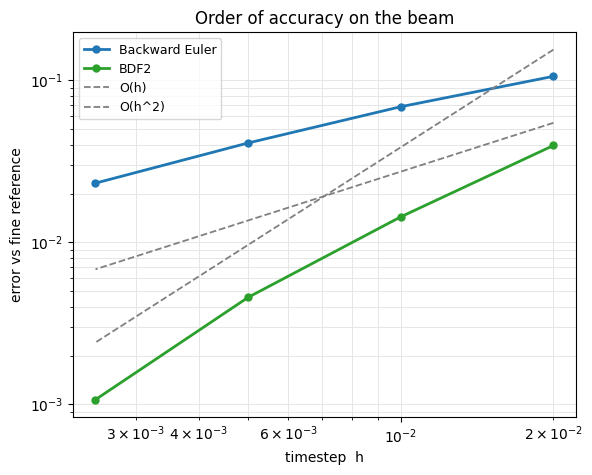

In [5]:
def integrate_exact(kind, h, T_total):
    """Step EXACTLY round(T_total / h) times so every dt ends at the same time."""
    steps = int(round(T_total / h))
    U, V = X.copy(), np.zeros_like(X)
    if kind == "Backward Euler":
        for _ in range(steps):
            U, V = be_step(U, V, h)
    else:                                            # BDF2, bootstrapped with one BE step
        U_next, V_next = be_step(U, V, h)
        U_prev, V_prev, U, V = U, V, U_next, V_next
        for _ in range(2, steps + 1):
            U_next, V_next = bdf2_step(U, V, U_prev, V_prev, h)
            U_prev, V_prev, U, V = U, V, U_next, V_next
    return U

T_total = 0.5
reference = integrate_exact("BDF2", 0.0003125, T_total)          # fine BDF2 reference
hs = np.array([0.02, 0.01, 0.005, 0.0025])
errors = {
    "Backward Euler": np.array([np.linalg.norm(integrate_exact("Backward Euler", h, T_total) - reference) for h in hs]),
    "BDF2":           np.array([np.linalg.norm(integrate_exact("BDF2", h, T_total) - reference) for h in hs]),
}
for name, e in errors.items():
    print(f"{name:16s} order ~ {np.polyfit(np.log(hs), np.log(e), 1)[0]:.2f}")

fig, _ = utils.loglog_plot(hs, errors, xlabel="timestep  h", ylabel="error vs fine reference",
    colors=utils.INTEGRATOR_COLORS, ref_slopes={"O(h)": 1, "O(h^2)": 2},
    title="Order of accuracy on the beam")
plt.show()

## Forward Euler explodes; Backward Euler doesn't (side by side)

Explicit integration is only stable below a tiny critical timestep (CFL). At
\(h = 0.008\) &mdash; a timestep Backward Euler handles without blinking
&mdash; **Forward Euler diverges within a few steps** and flies off-screen, while
Backward Euler calmly sags under gravity. This is *why* we use implicit
integrators for stiff elasticity.


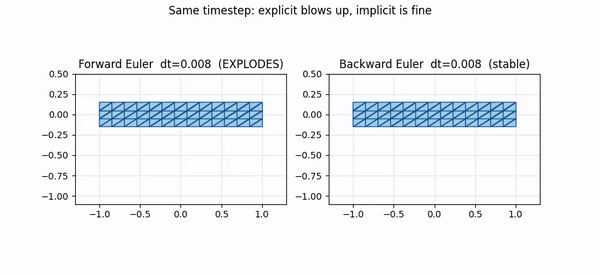

In [6]:
h_blow = 0.008
fe_states = simulate_fe(h_blow, 0.3, n_frames=40)
be_states = simulate_be(h_blow, 0.3, n_frames=40)
fig, anim = utils.animate_meshes_grid(
    [{"states": fe_states, "T": T, "title": f"Forward Euler  dt={h_blow}  (EXPLODES)"},
     {"states": be_states, "T": T, "title": f"Backward Euler  dt={h_blow}  (stable)"}],
    lims=((-1.3, 1.3), (-1.1, 0.5)), fps=20,
    suptitle="Same timestep: explicit blows up, implicit is fine")
utils.save_anim(anim, "media/07_fe_vs_be.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## Numerical damping: the timestep changes perceived stiffness

Release the beam under gravity and step **Backward Euler** at three (smooth,
stable) timesteps &mdash; 0.001, 0.010, 0.1. Larger dt &rarr; **more artificial
damping** &rarr; the swing dies out faster, so the material *looks* stiffer even
though the physics is identical.


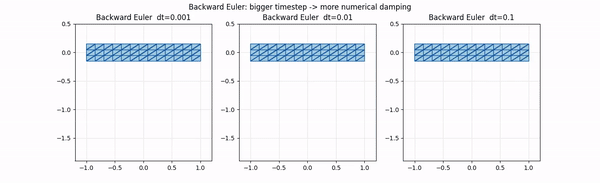

In [7]:
T_total = 3
dts = [0.001, 0.01, 0.1]
be_runs = [{"states": simulate_be(h, T_total, 60), "T": T, "title": f"Backward Euler  dt={h}"}
           for h in dts]
fig, anim = utils.animate_meshes_grid(be_runs, lims=((-1.2, 1.2), (-1.9, 0.5)), fps=30,
    suptitle="Backward Euler: bigger timestep -> more numerical damping")
utils.save_anim(anim, "media/07_be_damping.mp4", fps=30)
plt.close(fig)
utils.show_anim(anim)

## BDF2 barely damps

The same three timesteps with **BDF2**. It keeps swinging at all of them
&mdash; second-order accuracy buys far less numerical dissipation than Backward
Euler.


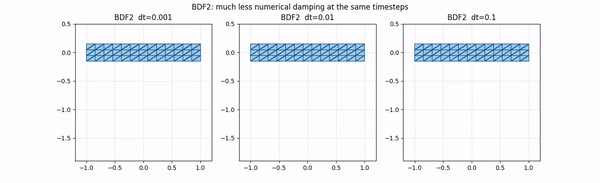

In [8]:
bdf2_runs = [{"states": simulate_bdf2(h, T_total, 60), "T": T, "title": f"BDF2  dt={h}"}
             for h in dts]
fig, anim = utils.animate_meshes_grid(bdf2_runs, lims=((-1.2, 1.2), (-1.9, 0.5)), fps=30,
    suptitle="BDF2: much less numerical damping at the same timesteps")
utils.save_anim(anim, "media/07_bdf2_damping.mp4", fps=30)
plt.close(fig)
utils.show_anim(anim)

## The damping, quantified: total energy bleeds away faster at bigger dt

The artificial damping isn't just visual &mdash; it removes **mechanical energy**.
We track the total energy (elastic + kinetic + gravitational) over time. For
Backward Euler the bigger the timestep, the **faster the energy drops**; BDF2
(shown for the largest dt) holds onto far more of it.

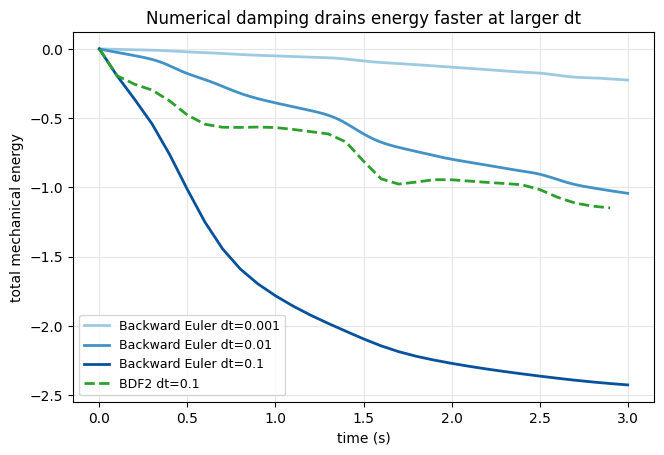

In [9]:
def total_energy(U, V):
    E_elastic = energies.macklin_mueller_neo_hookean_energy_x(U, J, mu, lam, vol)
    E_kinetic = 0.5 * float(V.flatten() @ (M @ V.flatten()))
    E_gravity = -(f_g.T @ U.reshape(-1, 1))[0, 0]
    E_total   = E_elastic + E_kinetic + E_gravity
    return E_total

def be_energy_trace(h, T_total):
    U, V = X.copy(), np.zeros_like(X)
    ts, Es = [0.0], [total_energy(U, V)]
    for s in range(int(T_total / h)):
        U, V = be_step(U, V, h); ts.append((s + 1) * h); Es.append(total_energy(U, V))
    return np.array(ts), np.array(Es)

def bdf2_energy_trace(h, T_total):
    U, V = X.copy(), np.zeros_like(X)
    Un, Vn = be_step(U, V, h); U_prev, V_prev, U, V = U, V, Un, Vn
    ts, Es = [0.0, h], [total_energy(X, np.zeros_like(X)), total_energy(U, V)]
    for s in range(2, int(T_total / h)):
        Un, Vn = bdf2_step(U, V, U_prev, V_prev, h)
        U_prev, V_prev, U, V = U, V, Un, Vn
        ts.append(s * h); Es.append(total_energy(U, V))
    return np.array(ts), np.array(Es)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
shades = ["#9ecae1", "#4292c6", "#08519c"]
for h, col in zip(dts, shades):
    ts, Es = be_energy_trace(h, T_total)
    ax.plot(ts, Es, color=col, lw=2, label=f"Backward Euler dt={h}")
ts, Es = bdf2_energy_trace(0.1, T_total)
ax.plot(ts, Es, color="#2ca02c", lw=2, ls="--", label="BDF2 dt=0.1")
ax.set_xlabel("time (s)"); ax.set_ylabel("total mechanical energy")
ax.set_title("Numerical damping drains energy faster at larger dt")
ax.grid(True, color="0.9"); ax.legend(fontsize=9); plt.show()

### Takeaways
* **Backward Euler** is order 1; **BDF2** is order 2 (verified on our own beam).
* **Forward Euler** is explicit and explodes unless dt is tiny &mdash; implicit
  methods stay stable at the same dt.
* **Backward Euler** damps motion (and *drains total energy*) more as dt grows;
  **BDF2** stays lively and conserves energy far better.